# Laboratorio 1: Python científico

Numpy, pandas y matplotlib son las tres librerías que vamos a usar todo el curso. Antes de meternos con modelos hay que practicar esto, así que vamos con ejemplos concretos.

## numpy

Con listas de Python, para sumarle 1 a cada elemento hay que hacer un `for`. Con numpy no.

In [ ]:
lista = [1, 2, 3, 4, 5]

resultado = []
for numero in lista:
    resultado.append(numero + 1)

print(resultado)

In [1]:
import numpy as np

array = np.array([1, 2, 3, 4, 5])
array + 1

array([2, 3, 4, 5, 6])

Con arrays grandes numpy es muchísimo más rápido porque hace las cuentas en C por debajo, no en Python puro. Lo podemos medir:

In [7]:
import time

numeros_lista = list(range(1_000_000))
numeros_array = np.arange(1_000_000)

inicio = time.time()
cuadrados_lista = [n ** 2 for n in numeros_lista]
print("con lista:", time.time() - inicio, "segundos")

inicio = time.time()
cuadrados_array = numeros_array ** 2
print("con numpy:", time.time() - inicio, "segundos")

con lista: 0.12386536598205566 segundos
con numpy: 0.0020792484283447266 segundos


Corran esa celda un par de veces. La diferencia va a variar según la máquina, pero numpy siempre gana y no por poco.

In [8]:
notas = np.array([7, 8, 4, 9, 6, 10, 3, 8])

print("promedio:", notas.mean())
print("la mas alta:", notas.max())
print("la mas baja:", notas.min())
print("cuantos aprobaron:", (notas >= 6).sum())
print("quienes aprobaron:", notas[notas >= 6])

promedio: 6.875
la mas alta: 10
la mas baja: 3
cuantos aprobaron: 6
quienes aprobaron: [ 7  8  9  6 10  8]


`notas >= 6` no filtra nada todavía, devuelve un array de `True`/`False`. Cuando lo usás para indexar (`notas[notas >= 6]`) ahí sí quedan solo con los que cumplen. Esto se llama indexado booleano y se usa todo el tiempo.

## pandas

Armamos una tabla a mano para no depender de ningún archivo. En la práctica esto casi siempre viene de un `pd.read_csv(...)`.

In [9]:
import pandas as pd

alumnos = pd.DataFrame({
    "nombre": ["Mora", "Bruno", "Zoe", "Tomas", "Julieta", "Nico", "Sol", "Ian"],
    "edad": [17, 18, 17, 17, 18, 17, 18, 17],
    "nota": [7, 8, 4, 9, 6, 10, 3, 8],
    "asistencia": [90, 75, 60, 95, 85, 100, 55, 80],
})

alumnos

,nombre,edad,nota,asistencia
0,Mora,17,7,90
1,Bruno,18,8,75
2,Zoe,17,4,60
3,Tomas,17,9,95
4,Julieta,18,6,85
5,Nico,17,10,100
6,Sol,18,3,55
7,Ian,17,8,80


In [10]:
alumnos.describe()

,edad,nota,asistencia
count,8.000000,8.000000,8.000000
mean,17.375000,6.875000,80.000000
std,0.517549,2.416461,16.035675
min,17.000000,3.000000,55.000000
25%,17.000000,5.500000,71.250000
50%,17.000000,7.500000,82.500000
75%,18.000000,8.250000,91.250000
max,18.000000,10.000000,100.000000


`describe()` te tira un resumen estadístico de cada columna numérica de una. Fíjense que a `nombre` la ignora porque es texto (y no nos gusta operar sobre texto).

Ahora algunas formas de recortar la tabla:

In [11]:
alumnos["nota"]

0     7
1     8
2     4
3     9
4     6
5    10
6     3
7     8
Name: nota, dtype: int64

In [12]:
alumnos[["nombre", "nota"]]

,nombre,nota
0,Mora,7
1,Bruno,8
2,Zoe,4
3,Tomas,9
4,Julieta,6
5,Nico,10
6,Sol,3
7,Ian,8


In [13]:
# solo los que aprobaron
alumnos[alumnos["nota"] >= 6]

,nombre,edad,nota,asistencia
0,Mora,17,7,90
1,Bruno,18,8,75
3,Tomas,17,9,95
4,Julieta,18,6,85
5,Nico,17,10,100
7,Ian,17,8,80


In [14]:
alumnos.sort_values("nota", ascending=False)

,nombre,edad,nota,asistencia
5,Nico,17,10,100
3,Tomas,17,9,95
7,Ian,17,8,80
1,Bruno,18,8,75
0,Mora,17,7,90
4,Julieta,18,6,85
2,Zoe,17,4,60
6,Sol,18,3,55


## matplotlib

Con la misma tabla, un plot de asistencia contra nota. La pregunta que nos podemos hacer es ¿el que más faltó es el que peor le fue?

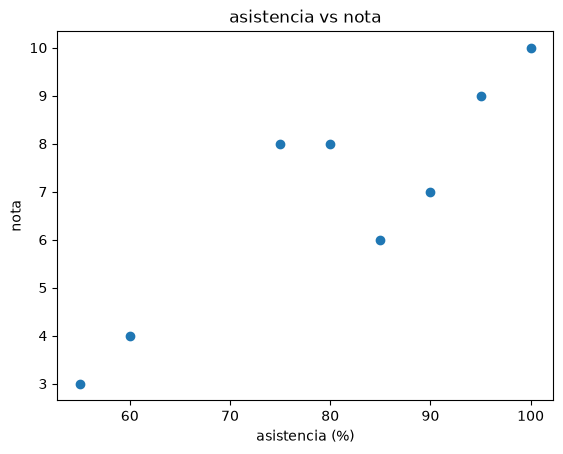

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(alumnos["asistencia"], alumnos["nota"])
ax.set_xlabel("asistencia (%)")
ax.set_ylabel("nota")
ax.set_title("asistencia vs nota")
plt.show()

No es una relación perfecta pero la tendencia se nota. Es el mismo tipo de gráfico que hicimos la clase pasada con Iris, solo que ahora armamos la tabla nosotros.

## Ejercicios

1. Agregar una columna nueva a `alumnos` llamada `aprobo` que diga `True` si `nota >= 6` y `False` si no.

2. Calcular el promedio de asistencia de solo los alumnos que aprobaron sin armar una tabla nueva.

3. Agregar 3 alumnos al DataFrame (pueden armar un DataFrame nuevo con `pd.concat` o directamente reescribir el diccionario de arriba con más datos) y graficar asistencia contra nota. ¿Cambia mucho la tendencia?

4. Generar un array de 20 números aleatorios entre 1 y 10 con numpy y calcular cuántos son mayores a 5 sin usar ningún `for`.

In [ ]:
# ejercicio 1


In [ ]:
# ejercicio 2


In [ ]:
# ejercicio 3


In [ ]:
# ejercicio 4
